
# Officer of the Watch (OOW) Agent — From COLREG Text to Agentic Training Data
## Auto Pilot Project · OOW Module

This notebook is the **OOW analogue of `VHF_Agent_Training_Pipeline.ipynb`**: same pipeline shape
(§0 setup → §1 eval data → §2 JSON → §3 RAG → §4 KG → §5 reasoning traces → §6 SFT/DPO/reflection →
§7 gold-claims → §8 Procedural Graph → §9 metrics explained → §10 baseline → §11 ablation → §12
quality gates → §13 fine-tune/merge/eval → §14 compression → §15 final comparison), pointed at a
different domain via `AUTOPILOT_DOMAIN=OOW` instead of hardcoding a second copy of every script.

### What the OOW agent is (see `Docs/Multi-Agent_Maritime_Navigation_System_Architecture_Plan rev JS v4.pdf`)

In the multi-agent ship's-bridge architecture, the **Officer of the Watch (= "Navigation Agent")**:
- receives parsed contact tracks from the **Perception/Lookout agent** (bearing, range, CPA/TCPA,
  encounter type) and own-ship position/state from the **Localization/Quartermaster agent** — both in
  natural language, not raw sensor data;
- runs pathfinding (A*/DWA) and **strictly applies COLREG** to decide the collision-avoidance action;
- outputs a **human-style helm + engine order** ("30 degrees port", "50 degrees starboard", "1 degree
  port"; engine "full ahead" / "full back" / "continue course") — **not** a raw MOOS `DESIRED_HEADING`/
  `DESIRED_SPEED` call. Translating that order into an exact rudder angle/RPM is the job of a separate,
  later **Actuator Agent (Helmsman)**, per the architecture doc's own phasing.
- Per the architecture doc §8 ("Language Models" / data-per-agent table): the Navigation Agent is
  fine-tuned on **COLREG + maritime training handbooks**; the Actuator/Perception/Localization agents
  need **no fine-tuning** (interface/translation layers only) — so this notebook is the one place real
  training work happens for this whole sub-tree. The "maritime training handbooks" half of that isn't
  just COLREG anymore: `OOW_Protocols/` now also has bearing/CPA-TCPA/radar-plotting reference material
  (`compass_directions_reference.md`, `tdgil_bearings.md`, `tdgil_cpa.md`, `free_radar_workbook.pdf`,
  `nav_maths_drills.json`), added to fix a confirmed TCPA-misread gap found via Basic Simulator mission
  runs, **plus `simple_colreg.json`** — a plain-English, example-driven explanation of every COLREG rule
  (already pre-chunked one entry per rule), a practical companion to the verbatim rule text rather than
  a replacement for it — see §2 for how all of these flow through the exact same JSON→RAG→KG→
  reasoning-trace pipeline as the COLREG text.

### Learning goals
- Reuse the *exact same* generic pipeline scripts as VHF (`pipeline/ingest`, `pipeline/track1`,
  `pipeline/train`, `pipeline/eval`, `pipeline/compress`), selected via the `AUTOPILOT_DOMAIN` env var
  (`core.AgentPaths.from_env()`), rather than forking a parallel copy of every script.
- Understand how COLREG's Track 1 (rules & knowledge) and Track 2 (applied helm/engine-order
  decision-making, see §6.5/§6.5.1) both feed the same fine-tune and are both validated end-to-end —
  at the base-Qwen baseline (§10/§10.1), the prompt ablation (§11/§11.1), and the fine-tuned/compressed
  model (§13.2/§13.3, §15) — analogous to how VHF validates both tracks at every stage. Track 2 now
  draws on two scenario sources: synthetic single-contact geometry (`build_oow_scenarios.py`) and real
  MOOS-simulated multi-contact trajectories (`build_oow_scenarios_leo.py`, §6.5.1), kept in separate
  `oow_scenario_*`/`oow_scenario_Leo_*` files for traceability.
- See §4 (Knowledge Graph) and §8 (Procedural Graphs) for how rule text, real incidents, and Track 2
  scenarios are each turned into retrieval structure — grouping *what-is* facts that belong together
  (§4) and *what-to-do* step sequences, including genuine "what actually went wrong" cases mined from
  real accidents (§8) — and how both feed prompt ablation (§11) and SFT (§6/§8).

### Model precision: 4-bit NF4 everywhere (by design)

Same choice as the VHF notebook (see that notebook's intro for the full rationale): every model
load here — training (§13) and evaluation/ablation/probes alike, local laptop and cloud pod alike —
uses 4-bit NF4 quantization (`--force-4bit`). Training needs this regardless of GPU (QLoRA is the only
way an 8B model's training state fits anywhere we run it); eval/ablation/probes use it purely for
consistent, apples-to-apples comparisons across model tags. If you ever have a GPU with much more VRAM
(40 GB+) and want the small bf16 quality/speed edge at eval time instead, drop `--force-4bit` from the
eval/probe calls — `load_lm()` already tries bf16 first and only falls back to 4-bit if it doesn't fit.


## Two tracks, from day one

| | Track 1 — COLREG rules & knowledge | Track 2 — Applied helm/engine-order decisions |
|---|---|---|
| Eval data (held out, NEVER used for training) | `Data/OOW/OOW_Eval/colreg_qa_500.json` (500 Q&A) | `Data/OOW/OOW_Eval/oow_colreg_scenarios.json` (300 scenarios, built by `pipeline/track2/build_oow_scenarios.py`) |
| Training data | `oow_sft_direct/cot/rag.jsonl`, `oow_multihop.jsonl`, `oow_dpo_pairs.jsonl`, `oow_reflection.jsonl`, `oow_pg_sft.jsonl` (now also fed by `OOW_Protocols/`'s supplementary bearing/CPA-TCPA/radar reference docs — see §2) | `oow_scenario_sft_direct/cot.jsonl`, `oow_scenario_dpo_pairs.jsonl`, `oow_scenario_reflection.jsonl` **+** `oow_scenario_Leo_sft_direct/cot.jsonl`, `oow_scenario_Leo_dpo_pairs.jsonl`, `oow_scenario_Leo_reflection.jsonl` (real MOOS-trajectory scenarios, §6.5.1 — reviewed n=25 sample so far, kept in separate files for traceability) |
| Eval script | `pipeline/eval/eval_finetuned.py --gold-file colreg_qa_500_normalised.json` | `pipeline/eval/eval_oow_scenarios.py` |

Both tracks feed the **same** QLoRA fine-tune (§13's `SFT_DATASETS`/`DPO_FILES`/`REFL_FILES` already
list both tracks' files, including the Leo scenario files, for OOW) and are evaluated at every stage —
base Qwen (§10/§10.1), prompt ablation (§11/§11.1), and the fine-tuned/compressed model (§13.2/§13.3,
§15) — exactly like VHF. See §6.5/§6.5.1 for how Track 2's scenarios/training data were built.



## Repository layout — where OOW data & models live

```
Data/OOW/                          ← AgentPaths.oow().data_root
├── OOW_Protocols/                 ← source_dir   (training documents: COLREG-Consolidated-2018.pdf,
│                                     compass_directions_reference.md, tdgil_bearings.md, tdgil_cpa.md,
│                                     free_radar_workbook.pdf, nav_maths_drills.json,
│                                     simple_colreg.json -- see § 2)
├── OOW_Eval/                      ← eval_dir     (held-out evaluation)
│   └── colreg_qa_500.json         ← gold Q&A (500 items) — NOT the default oow_gold_answers.json name,
│                                     loaded explicitly via --gold-file everywhere in this notebook
├── OOW_JSON/                      ← json_dir     (§ 2 output -- one JSON per source document)
├── OOW_Agents_Training/           ← cache_dir    (RAG/KG/traces/SFT/DPO/reflection)
├── OOW_Incidents/                 ← real accident-investigation reports (§ 5.1 input, ~800 PDFs)
├── OOW_Scenarios_Leo/              ← real MOOS-trajectory bridge states (§ 6.5.1 input, 7928 records)
├── OOW_Literature_Review/         ← background research (not a pipeline input)
└── OOW_MOOS_Integration/          ← colreg_llm_bridge.py + MOOS scenario/eval scaffolding (Track 2 input, later)
_models/OOW/                       ← domain_models_dir (adapters + merged OOW-QWEN)
```

This mirrors VHF's layout exactly (see that notebook's own "Repository layout" section) — only the
`Data/<domain>` segment and the two domain-specific filenames (`OOW_Protocols`, `colreg_qa_500.json`)
differ. Every path below comes from `AgentPaths.oow()` (equivalently, `AgentPaths.from_env()` with
`AUTOPILOT_DOMAIN=OOW`) — never hardcoded — so this notebook and the shared pipeline scripts can never
silently diverge on where things live.


---
## § 0 — Environment Setup

Same dependency set as the VHF notebook (this is a workspace-wide `.venv`, not domain-scoped) — safe to
skip if you already ran VHF's § 0 in this environment.

In [1]:
import subprocess, sys, time

packages = [
    # Core inference (API clients)
    "openai>=1.40.0",
    "anthropic>=0.34.0",
    "tiktoken>=0.7.0",
    # Retrieval / embeddings
    "sentence-transformers>=2.7.0",
    "scikit-learn>=1.4.0",
    # Data
    "pandas>=2.2.0",
    "numpy>=1.26.0",
    "networkx>=3.2",
    # PDF extraction
    "pdfplumber>=0.11.0",
    # Progress + plotting
    "tqdm>=4.66.0",
    "matplotlib>=3.8.0",
    # HuggingFace stack (torch is installed separately in § 0.2 with CUDA support)
    "transformers>=4.40.0",
    "peft>=0.10.0",
    "trl>=0.8.0",
    "accelerate>=0.29.0",
]

t0 = time.time()
print("[setup] Installing / verifying dependencies (excluding torch)...", flush=True)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print(f"[setup] Done in {time.time()-t0:.1f}s", flush=True)

print("\n[setup] Installing bitsandbytes (for 4-bit Qwen quantisation)...", flush=True)
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes>=0.43.0"])
    print("[setup] bitsandbytes installed OK")
except subprocess.CalledProcessError as e:
    print(f"[setup] bitsandbytes install failed ({e}). Qwen will load in bf16 instead of 4-bit.")

[setup] Installing / verifying dependencies (excluding torch)...
[setup] Done in 0.9s

[setup] Installing bitsandbytes (for 4-bit Qwen quantisation)...
[setup] bitsandbytes installed OK


### § 0.1 — Domain selection

Every subsequent cell in this notebook — and every `pipeline.*` subprocess it launches — targets the
**OOW** domain via this one environment variable (`core.AgentPaths.from_env()` reads it). This is the
only line that differs from an equivalent VHF cell.

In [2]:
import os
from pathlib import Path
from core import AgentPaths

os.environ["AUTOPILOT_DOMAIN"] = "OOW"

paths = AgentPaths.oow()
W = paths.workspace
GOLD_FILE = paths.eval_file("colreg_qa_500.json")   # NOT paths.gold_file -- see repo-layout note above

print(paths.describe())
print(f"\ngold Q&A file exists: {GOLD_FILE.exists()}  ({GOLD_FILE})")

  domain             OOW
  workspace          C:\Users\jcsch\Documents\Python\Auto Pilot
  source_dir         C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Protocols
  eval_dir           C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval
  gold_file          C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval\oow_gold_answers.json
  json_dir           C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_JSON
  cache_dir          C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training
  hf_cache_dir       C:\Users\jcsch\Documents\Python\Auto Pilot\_models\hf_cache
  domain_models_dir  C:\Users\jcsch\Documents\Python\Auto Pilot\_models\OOW
  env_file           C:\Users\jcsch\Documents\Python\Auto Pilot\.env

gold Q&A file exists: True  (C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval\colreg_qa_500.json)


### § 0.2 — CUDA-aware PyTorch + GPU sanity check

Identical to VHF's § 0.1/§ 0.2 — copy verbatim since this is workspace-level, not domain-scoped.

In [ ]:
import subprocess, sys, shutil, time

def _detect_nvidia_gpu() -> tuple[bool, str]:
    if shutil.which("nvidia-smi") is None:
        return False, "nvidia-smi not found on PATH"
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
             "--format=csv,noheader"],
            text=True, timeout=10,
        ).strip()
        return True, out
    except Exception as e:
        return False, f"nvidia-smi failed: {e}"

has_gpu, gpu_info = _detect_nvidia_gpu()
print(f"[gpu-detect] {gpu_info}")

try:
    import torch
    need_reinstall = has_gpu != torch.cuda.is_available()
except ImportError:
    need_reinstall = True

if need_reinstall:
    index_url = "https://download.pytorch.org/whl/cu128" if has_gpu else "https://download.pytorch.org/whl/cpu"
    t0 = time.time()
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--upgrade",
        "torch", "torchvision", "torchaudio", "--index-url", index_url,
    ])
    print(f"[install] Done in {time.time()-t0:.1f}s -- RESTART THE KERNEL, then re-run.")
else:
    print("[install] Skipped: existing torch already matches the desired CUDA state.")

[gpu-detect] NVIDIA GeForce RTX 4070 Laptop GPU, 596.08, 8188 MiB
[install] Skipped: existing torch already matches the desired CUDA state.


In [4]:
import torch
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}  ({props.total_memory/1024**3:.1f} GB)")
    try:
        import bitsandbytes as bnb
        print(f"bitsandbytes {bnb.__version__} OK")
    except Exception as e:
        print(f"bitsandbytes not available ({e}) -- Qwen will load in bf16 instead of 4-bit.")
else:
    print("No CUDA -- fine-tuning/eval will fall back to CPU (very slow). See VHF notebook § 0.2 for fixes.")

PyTorch        : 2.6.0+cu124
CUDA available : True
GPU 0: NVIDIA GeForce RTX 4070 Laptop GPU  (8.0 GB)
bitsandbytes 0.50.2 OK


### § 0.3 — Smoke-test toggle

Same toggle as the VHF notebook § 0.3 -- one switch for a small, cheap, fast smoke run vs the full batch (meant for the cloud pod). Every eval/ablation/probe cell below reads `SMOKE_TEST` via the `n_arg()`/`smoke_tag()` helpers.


In [5]:
import os

# SMOKE_TEST=True -> small n, fast/cheap, to check the pipeline actually works end to end.
# Set to False (or export AUTOPILOT_SMOKE_TEST=0 before starting Jupyter) to run the full
# batch -- that's what the cloud pod's run_all.sh does (calls the .py scripts directly,
# never this toggle).
SMOKE_TEST = os.environ.get("AUTOPILOT_SMOKE_TEST", "1") == "1"
SMOKE_N = int(os.environ.get("AUTOPILOT_SMOKE_N", "2"))

# DRY_RUN=True -> §13-§14.2 validate their data/args/paths and write a stub adapter/model
# WITHOUT ever loading the real model (zero GPU memory) -- safe to run on the laptop even
# though real training/compression must never happen locally. Independent of SMOKE_TEST:
# SMOKE_TEST still loads the real model (small/fast, cloud-only); DRY_RUN loads nothing.
DRY_RUN = os.environ.get("AUTOPILOT_DRY_RUN", "0") == "1"


def n_arg(full_n: int) -> list[str]:
    """--n flag for eval/ablation CLI calls: SMOKE_N in smoke mode, else the full set size."""
    return ["--n", str(SMOKE_N if SMOKE_TEST else full_n)]


def smoke_tag(tag: str) -> str:
    """Appends _smoke so a smoke run never shares a summary/answers file with a full run
    (and can't be mistaken for one by ensure_and_print's skip-if-done check)."""
    return f"{tag}_smoke" if SMOKE_TEST else tag


def probe_smoke_args() -> list[str]:
    """Optional smaller probe set / reflection sample while smoke-testing."""
    return ["--per-axis", "5", "--n-reflect", "5"] if SMOKE_TEST else []


def ablation_tag_args() -> list[str]:
    """--tag for prep_ablation.py/run_ablation.py/score_ablation.py: keeps a smoke-test
    sample's prompts/answers/scored/summary files completely separate from a full run's --
    run_ablation.py APPENDS to its answers file and score_ablation.py scores the WHOLE file,
    so without this a smoke run would score every answer ever generated, not just its own."""
    return ["--tag", "smoke"] if SMOKE_TEST else []


def smoke_model_dir(name: str) -> str:
    """OOW-QWEN -> OOW-QWEN_smoke, oow_qwen_sft_lora -> oow_qwen_sft_lora_smoke, etc.
    Applied to every adapter/model dir the §13-§14.2 stages read or write, so a smoke
    chain never overwrites (or is mistaken for) a real 24h run's artifacts."""
    return f"{name}_smoke" if SMOKE_TEST else name


def smoke_dir(name: str) -> Path:
    """Full path under domain_models_dir for `name`, smoke-suffixed when SMOKE_TEST."""
    return paths.domain_models_dir / smoke_model_dir(name)


def smoke_train_args(max_steps: int = 3) -> list[str]:
    """--max_steps cap for train_sft.py/train_dpo.py/train_reflection.py (underscore flag,
    matching their existing argparse convention) -- each script already supported this cap
    for smoke tests, it just wasn't wired to SMOKE_TEST yet."""
    return ["--max_steps", str(max_steps)] if SMOKE_TEST else []


def smoke_distill_args(max_steps: int = 3) -> list[str]:
    """--max-steps cap for compress_distill.py (hyphenated, matching ITS argparse convention)."""
    return ["--max-steps", str(max_steps)] if SMOKE_TEST else []


def dry_run_args() -> list[str]:
    """--dry-run for every §13-§14.2 script: validates data/args/paths and writes a stub
    output without loading the real model. Safe to run locally; combine with SMOKE_TEST=False
    to pre-flight the FULL data files before committing to the real 24h cloud run."""
    return ["--dry-run"] if DRY_RUN else []


print(f"SMOKE_TEST = {SMOKE_TEST}  (n={SMOKE_N if SMOKE_TEST else 'full'})")
print(f"DRY_RUN    = {DRY_RUN}")


SMOKE_TEST = True  (n=2)
DRY_RUN    = False


---
## § 1 — Load the existing COLREG gold Q&A set

Unlike VHF (§1-3: parse raw exam text, then LLM-generate gold answers), OOW's Track 1 eval set
(`colreg_qa_500.json`) **already exists**, hand-built with schema
`{id, category, rule_ref, question_type, question, answer, explanation, difficulty}` spanning COLREG
Parts A-E and Annexes I-IV (see `Data/OOW/OOW_Eval/README.md`). We just load and sanity-check it here;
no generation step is needed. Note the field is `answer`, not `gold_answer` as in VHF's schema --
downstream scripts that expect `gold_answer`/`expected_points` (contamination filters, `eval_finetuned.py`)
need this file normalised first, which the cell below does into a `*_normalised.json` copy.

In [6]:
import json

raw_gold = json.loads(GOLD_FILE.read_text(encoding="utf-8"))
print(f"Loaded {len(raw_gold)} COLREG Q&A records from {GOLD_FILE.name}")
print("Sample record keys:", list(raw_gold[0].keys()))

# Normalise to the {question, gold_answer, expected_points} shape every shared
# pipeline script (contamination filters, eval_finetuned.py) expects.
NORM_FILE = paths.eval_dir / "colreg_qa_500_normalised.json"
normalised = [
    {
        "id":               r["id"],
        "section_id":       r.get("rule_ref", r.get("category", "")),
        "section_title":    r.get("category", ""),
        "type":             r.get("question_type", ""),
        "question":         r["question"],
        "gold_answer":      r.get("answer", ""),
        "expected_points":  [r["explanation"]] if r.get("explanation") else [],
    }
    for r in raw_gold
]
NORM_FILE.write_text(json.dumps(normalised, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote normalised copy: {NORM_FILE}  ({len(normalised)} rows)")

import pandas as pd
df = pd.DataFrame(raw_gold)
if "category" in df.columns:
    print(df["category"].value_counts())

Loaded 500 COLREG Q&A records from colreg_qa_500.json
Sample record keys: ['id', 'category', 'rule_ref', 'question_type', 'question', 'answer', 'explanation', 'difficulty']
Wrote normalised copy: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval\colreg_qa_500_normalised.json  (500 rows)
category
Part C - Lights and Shapes             100
Section II - Scenario                   86
Section I - Any Visibility              63
Part D - Sound and Light Signals        43
Annex I                                 41
Section II - In Sight                   38
Section III - Restricted Visibility     32
Annex IV                                23
Part A - General                        21
Annex III                               20
Annex II                                19
Part E - Exemptions                     14
Name: count, dtype: int64


---
## § 2 — Convert COLREG source documents to structured JSON

VHF's § 2 lives entirely as a standalone script because it has to cope with ~45 heterogeneous
documents. OOW's Track 1 core source is a single, very regularly structured official text, so this is
a small standalone script too: `pipeline/ingest/build_oow_json.py` (Convention Articles I-IX → PART
A-E / Rule 1-38 → Annexes I-IV, ~105 sections). See that script's docstring for the exact schema.

**Supplementary docs (added this pass)**: five more files dropped into `OOW_Protocols/` --
`compass_directions_reference.md`, `tdgil_bearings.md`, `tdgil_cpa.md` (bearings/CPA reference
material fetched from tdgil.com), `free_radar_workbook.pdf` (a 20-page radar-plotting workbook), and
`nav_maths_drills.json` (91 hand-written TCPA/CPA/bearing drill Q&A, written to fix a confirmed
TCPA-misread gap found via Basic Simulator mission runs -- see `Data/basic_nav_knowledge_gaps.json`).
The SAME `build_oow_json.py` cell below now also parses these via `build_extra_docs()` -- generic
`#`/`##` heading splitting for the three .md files, a "Lesson N.N" heading split for the PDF, and a
direct Q&A→section conversion for the drills JSON (see that function's docstring) -- and writes one
JSON per document into `OOW_JSON/`, same schema as the COLREG file, so § 3 (RAG)/§ 4 (KG) pick them up
automatically with no further wiring. `CONCEPT_KEYWORDS` also gained bearing/CPA/TCPA/radar-plotting
vocabulary so these new sections get tagged for KG retrieval like everything else (see that dict).

**`simple_colreg.json` (added later)**: a plain-English, example-driven explanation of every COLREG
rule, hand-authored and already pre-chunked one record per rule (`chunk_id`, `part`, `rule_ref`,
`title`, `plain_explanation`, `examples`, `official_text`, `chunk_text`) -- a practical companion to
`colreg_consolidated_2018.json`'s verbatim legal text, not a replacement for it: the raw rule text is
already indexed from that file, so this new doc is parsed via `parse_simple_colreg()` to index only
each record's `chunk_text` (title + plain-English explanation + worked example), avoiding indexing the
same legal text twice under two document_ids. Records are grouped into chapters by their own `part`
field and each becomes a standalone `"rule"`-typed section (same `STANDALONE_TYPES` guarantee as the
official text -- `build_rag.py` never merges a rule chunk with its neighbour), tagged via the same
`tag_text()`/`CONCEPT_KEYWORDS` as everything else in this section, so it flows into § 3 (RAG) and § 4
(KG) automatically with zero extra wiring.



In [7]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_oow_json"], cwd=W)

0

---
## § 3 — Build RAG chunks from JSON

Same chunker as VHF (`pipeline/ingest/build_rag.py`), unchanged -- just reads from `OOW_JSON/` and
writes `oow_rag_chunks.json` / `oow_rag_embeddings.npy` / `oow_rag_chunk_ids.json` into
`OOW_Agents_Training/` instead of the `vhf_*` equivalents.


In [8]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_rag"], cwd=W)

0

---
## § 4 — Knowledge-Graph RAG: grouping semantically-related fragments

Same KG builder as VHF (`pipeline/ingest/build_kg.py`): a concept co-occurrence graph over the RAG
chunks (§ 3), so retrieval expands from a dense hit to other chunks that share a concept, instead of
jumping to unrelated parts of the corpus. Two separate concept mechanisms feed it, and only one of
them is COLREG-aware today:

- **`CONCEPT_KEYWORDS`** (in `pipeline/ingest/build_oow_json.py`, applied to every chunk at parse
  time -- `colreg_consolidated_2018.json`, the incident excerpts, AND the § 2 supplementary docs
  (bearings/CPA-TCPA/radar-plotting reference material, nav-maths drills) all reuse the exact same
  `tag_text()`) is what actually populates the KG's `concept_chunks`/`concept_cooccur` structures, so
  this is the mechanism that determines whether semantically-related fragments really do end up
  co-located in the graph. It started as 22 COLREG rule-text keywords (give-way, crossing, sound
  signal, ...), was **extended with ~20 incident/human-factors terms**
  (`lookout_failure`, `fatigue`, `radar_arpa`, `bridge_resource_management`, `casualty`,
  `investigation_finding`, ...) once the KG-quality check below showed real accident reports use
  entirely different vocabulary than rule text and were going almost untagged (zero-concept incident
  chunks dropped from 36% to 16% of the corpus, `stats.n_concepts` 21 → 34), and most recently gained
  a third batch (`true_bearing`, `magnetic_bearing`, `relative_bearing`, `cpa_tcpa`,
  `radar_plotting`, `compass_convention`) for the new bearing/CPA-TCPA/radar docs, for the same
  reason -- none of the rule-text or incident keywords ever appear in them either.
- **`CONCEPT_ALIASES`** (in `pipeline/ingest/build_kg.py`, used only at *query* time to expand an
  informally-worded question to a known concept) now has an OOW-specific alias table (`cpa`/`tcpa`/
  `crossing`/`give-way`/`stand-on`/`risk of collision`/...), fixing a confirmed bug where the previous
  VHF-only table contributed zero alias hits for any OOW query -- e.g. `narrate()`'s situation reports
  are almost entirely numeric ("CPA 0m, TCPA 206s") and matched no concepts at all, leaving retrieval
  to dense-embedding-only matching (found via Basic Simulator S02 mission testing: v3_rag_cot retrieved
  ZERO COLREG rule chunks for a live crossing/collision-risk scenario, only numerically-similar
  bearing-drill Q&A).

**Why this matters for retrieval quality**: without concept tags, a chunk is only ever found via
dense embedding similarity -- it never gets the concept-co-occurrence *boost* that pulls in
neighbouring, thematically-linked chunks, so retrieval for that chunk's topic stays shallow. This was
the concrete quality problem found (and partly fixed) here -- see § 8 for the equivalent
investigation and fix on the Procedural Graph side.


In [9]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_kg"], cwd=W)

0

---
## § 5 — Reasoning-trace extraction

Same extraction driver as VHF (`pipeline/track1/extract_reasoning.py`), with a COLREG-specific
`SYSTEM_PROMPT` variant selected automatically by `paths.domain`. It reuses VHF's exact trace schema
field names for mechanical compatibility with every downstream script -- see the prompt for the
mapping (`channels` → COLREG rule numbers, `prowords_used` → vessel-role/situational tags,
`regulations` → instruments like "COLREG 1972"). Needs `OPENAI_API_KEY`; resume-safe (only calls the
LLM for chunk_ids missing from the output file).


In [10]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.extract_reasoning"], cwd=W)

0

---
## § 5.1 — Real-world incident reports (screen → excerpt → extract)

`Data/OOW/OOW_Incidents/` has ~800 real marine accident-investigation reports (UK MAIB + US
NTSB/USCG). Most are groundings/fires/flooding/machinery-failure cases with no COLREG angle, so we
can't just feed the whole corpus in. Three-stage local pipeline, mirroring § 2-§ 5 above but for
incidents instead of the rule text:

1. **`pipeline/ingest/screen_incidents.py`** — scores every PDF on COLREG-vocabulary density minus
   non-COLREG signal (grounding/fire/flooding/...), writes a ranked
   `incident_screening.json` (no LLM, just keyword counting).
2. **`pipeline/ingest/build_incident_excerpts.py`** — for reports scoring `net_score >= 15`, keeps only
   the report's opening summary + its Analysis/Conclusions/Findings pages (not the whole report),
   saved as `Data/OOW/OOW_JSON/incident_*.json` in the same schema as `colreg_consolidated_2018.json`
   so § 3/§ 4 (RAG/KG) would pick them up unchanged if re-run.
3. **`pipeline/track1/extract_incident_reasoning.py`** — GPT-4o-mini extraction, ONE trace per
   incident document (not per chunk, since each excerpt is already a single bounded unit). Schema
   reuses the § 5 field names (`situation`/`procedures`/`channels`/... ) for mechanical
   compatibility with every § 6 builder below, plus an additive `incident` sub-object (vessels/
   roles, fault attribution, actual-vs-correct actions, exceptional circumstances, confidence). The
   model also self-filters: reports that turn out NOT to be vessel-vs-vessel collision-avoidance
   situations return `{"skip": true, ...}` instead of a trace.


In [11]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.screen_incidents"], cwd=W)

0

In [12]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_incident_excerpts",
                       "--min-score", "15"], cwd=W)

0

In [13]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.extract_incident_reasoning"], cwd=W)

0

---
## § 6 — Track 1 training-data generation (deterministic, no LLM required)

Same four builders as VHF's Track 1, called with `--out-prefix oow_sft` / `--gold-file` pointed at the
normalised COLREG Q&A so contamination filtering works correctly.


In [14]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_sft",
    "--out-prefix", "oow_sft", "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [15]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_multihop",
    # Rule-text traces all share ONE source_file (COLREG-Consolidated-2018.pdf) so on
    # their own they can never satisfy build_multihop.py's "different source documents"
    # requirement -- adding the incident traces (each its own source_file) and the
    # scenario traces (each its own synthetic source_file, oow_scenario_generator::<category>)
    # is what unlocks real cross-source pairs (rule text <-> incident <-> scenario).
    "--traces-file", str(paths.cache_dir / "oow_reasoning_traces.jsonl"),
                     str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
                     str(paths.cache_dir / "oow_scenario_reasoning_traces.jsonl"),
    "--out-file", str(paths.cache_dir / "oow_multihop.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [16]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_rlhf",
    "--out-file", str(paths.cache_dir / "oow_dpo_pairs.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [17]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_reflection",
    "--out-file", str(paths.cache_dir / "oow_reflection.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

---
## § 6.1 — Track 1 training data from real incident excerpts

Same four deterministic builders, pointed at `oow_incident_reasoning_traces.jsonl` (§ 5.1) instead
of the rule-text traces, with their own `oow_incident_*` output files (kept separate from `oow_sft_*`
etc. for traceability, same convention as VHF's Track 1 / Track 2 split). Cross-track multi-hop pairs
(rule text <-> incident) are already produced by the § 6 `build_multihop` cell above, since it's
pointed at both traces files together -- nothing to do here for multi-hop.


In [18]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_sft",
    "--traces-file", str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-prefix", "oow_incident_sft", "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [19]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_rlhf",
    "--traces-file", str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-file", str(paths.cache_dir / "oow_incident_dpo_pairs.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [20]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_reflection",
    "--traces-file", str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-file", str(paths.cache_dir / "oow_incident_reflection.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [21]:
# Row-count sanity check across everything § 6 / § 6.1 produced.
for name in ["oow_sft_direct.jsonl", "oow_sft_cot.jsonl", "oow_sft_rag.jsonl",
             "oow_multihop.jsonl", "oow_dpo_pairs.jsonl", "oow_reflection.jsonl",
             "oow_incident_sft_direct.jsonl", "oow_incident_sft_cot.jsonl", "oow_incident_sft_rag.jsonl",
             "oow_incident_dpo_pairs.jsonl", "oow_incident_reflection.jsonl"]:
    p = paths.cache_dir / name
    n = sum(1 for _ in p.open(encoding="utf-8")) if p.exists() else 0
    print(f"  {name:<30} {n:>5} rows" if p.exists() else f"  {name:<30} MISSING")


  oow_sft_direct.jsonl            1253 rows
  oow_sft_cot.jsonl               1253 rows
  oow_sft_rag.jsonl               1253 rows
  oow_multihop.jsonl              1541 rows
  oow_dpo_pairs.jsonl             1585 rows
  oow_reflection.jsonl             346 rows
  oow_incident_sft_direct.jsonl    214 rows
  oow_incident_sft_cot.jsonl       214 rows
  oow_incident_sft_rag.jsonl       214 rows
  oow_incident_dpo_pairs.jsonl     216 rows
  oow_incident_reflection.jsonl     66 rows


---
## § 6.5 — Track 2: applied helm/engine-order decisions (built, now wired into eval)

This is the piece the user's spec calls out explicitly: given a fused situation report (contacts with
bearing/range/CPA/TCPA/encounter-type from the Lookout agent + own-ship state from the Quartermaster
agent), the OOW must output a **natural-language helm order** ("30 degrees port", "1 degree port", "50
degrees starboard") and **engine order** ("full ahead", "full back", "continue course") -- not raw MOOS
calls (that translation is the later Actuator Agent's job).

**Built** — analogous to VHF's Track 2 (`pipeline/track2/build_vhf_*`), added after Track 1 was working
end-to-end:

1. **Scenario source**: [build_oow_scenarios.py](pipeline/track2/build_oow_scenarios.py) generates the
   scenarios procedurally (bearing/range/own-speed/target-speed geometry per encounter category:
   head-on, crossing give-way/stand-on, overtaking, plus multi-contact composites), analogous to
   `build_vhf_colreg_scenarios.py`'s category list.
2. **Deterministic action + Claude-authored justification prose**: the give-way/stand-on action and its
   parameters are computed closed-form from CPA/TCPA geometry (never left to an LLM); Claude only
   renders the fluent `gold_answer` prose around the already-decided action -- same "fluent prose,
   never telegraphic label:value dumps" requirement as every other training-data builder in this repo.
3. **Contamination filter**: training `gold_answer` text is cosine-filtered against Track 1's
   `colreg_qa_500.json` at 0.85, same convention as VHF.
4. **Held-out eval set**: `Data/OOW/OOW_Eval/oow_colreg_scenarios.json` (300 scenarios, geometrically
   disjoint from the training scenarios) + its `_claims.json` gold-claims enrichment.
5. **Eval harness**: [eval_oow_scenarios.py](pipeline/eval/eval_oow_scenarios.py) — rule-based
   ActionCorrect/DirectionCorrect/RuleCite plus the claim-level RAGAS suite v2. Wired into § 10.1
   (baseline), § 11.1 (ablation), and § 13.3 (fine-tuned eval) below.
6. **MOOS-in-the-loop evaluation** (`colreg_llm_bridge.py` / `colreg_llm_bridge_paused.py`) stays a
   later phase, once the LLM reliably produces correct helm/engine orders in this text-only setting.

Training data (`oow_scenario_sft_*.jsonl`, `oow_scenario_dpo_pairs.jsonl`, `oow_scenario_reflection.jsonl`,
mined from the deterministic reasoning traces below) is already wired into `train_sft.py`/`train_dpo.py`/
`train_reflection.py`'s `SFT_DATASETS`/`DPO_FILES`/`REFL_FILES` lists for OOW -- no further action needed
before § 13.



---
## § 6.5.1 — Track 2 augmentation: the Leo MOOS-trajectory dataset

[build_oow_scenarios_leo.py](pipeline/track2/build_oow_scenarios_leo.py) re-renders
`Data/OOW/OOW_Scenarios_Leo/moos_temporal_narratives_final.jsonl` (7928 REAL MOOS-simulated bridge
states across 402 multi-step trajectories) into the same house prose style as § 6.5's synthetic
scenarios -- richer situations (0-6 simultaneous contacts, sensor-realism fields, multiple encounter/
risk vocabularies) than `build_oow_scenarios.py`'s single-contact geometry can generate. Deterministic
action + Claude-authored justification, same BUILD-vs-VALIDATE split, same 0.85 contamination filter.

**Current status**: a **reviewed n=25 sample**, not the full 7928-record set -- kept in its own
`oow_scenario_Leo_*.jsonl` files (never merged into the plain `oow_scenario_*.jsonl` files from § 6.5)
so this source's contribution stays independently traceable, per explicit user direction. Now wired
into `train_sft.py`/`train_dpo.py`/`train_reflection.py`'s `SFT_DATASETS`/`DPO_FILES`/`REFL_FILES` for
OOW (previously generated but never referenced by any training file list) and into § 8's merged PG
(`build_pg.py`'s default trace auto-discovery now also picks up
`oow_scenario_Leo_reasoning_traces.jsonl` if present).

**Scaling up beyond n=25** is a deliberate follow-up, not done automatically here (the script's own
docstring: "SAMPLE/REVIEW pass... do that only after the sample's reviewed" -- more Claude API calls,
real cost): rerun with a larger `--n` (or drop `--n` for the whole 402-trajectory set) once ready.
A dedicated Leo-scoped PG (mirroring `oow_pg_rule.json`/`_incident.json`/`_scenario.json`) is also
deferred for the same reason -- Leo traces currently only flow into the *merged* graph.



In [ ]:
# Skip-if-present (like every other resume-safe cell here) -- this makes real Claude API
# calls, so don't silently re-spend money regenerating the already-reviewed n=25 sample.
# To scale up deliberately: delete oow_scenario_Leo_reasoning_traces.jsonl (or just bump
# --n) and re-run this cell.
_leo_traces = paths.cache_dir / "oow_scenario_Leo_reasoning_traces.jsonl"
if _leo_traces.exists():
    _n = sum(1 for _ in _leo_traces.open(encoding="utf-8"))
    print(f"[skip] {_leo_traces.name} already exists ({_n} rows) -- delete it to regenerate/rescale.")
else:
    subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m",
                           "pipeline.track2.build_oow_scenarios_leo", "--n", "25"], cwd=W)

# Row-count sanity check, same pattern as the § 6/§ 6.1 cell above.
for name in ["oow_scenario_Leo_reasoning_traces.jsonl", "oow_scenario_Leo_sft_direct.jsonl",
            "oow_scenario_Leo_sft_cot.jsonl", "oow_scenario_Leo_dpo_pairs.jsonl",
            "oow_scenario_Leo_reflection.jsonl"]:
    p = paths.cache_dir / name
    n = sum(1 for _ in p.open(encoding="utf-8")) if p.exists() else 0
    print(f"  {name:<40} {n:>5} rows" if p.exists() else f"  {name:<40} MISSING")


---
## § 7 — Gold-standard file + atomic-claim enrichment (metric suite v2 prerequisite)

Every evaluation below (§ 11 ablation scoring, § 13 eval) defaults to the **claim-level RAGAS suite
v2** ([ragas_metrics.py](pipeline/eval/ragas_metrics.py)) — same suite, same composites and same
paired-bootstrap CIs as VHF (see the VHF notebook § 9 for the full metric table and the rationale
for replacing the old whole-answer binary Faith judge). The suite needs each gold record decomposed
into atomic `gold_claims` — this section documents the required gold format and runs the one-off
enrichment for OOW.

### How the OOW gold-standard file must look

`Data/OOW/OOW_Eval/colreg_qa_500_normalised.json` (500 records, **held out** — nothing derived from it
may ever enter training data; every builder cosine-filters against it at 0.85):

```json
{"id": "colreg_0001",
 "section_id": "Rule 15",            ← rule reference (used for gap analysis grouping)
 "section_title": "Crossing situation",
 "type": "recall | scenario | why",
 "question": "…one exam-style question…",
 "gold_answer": "…terse but fluent reference answer…",
 "expected_points": ["…atomic examinable point(s)…"]}
```

### The `gold_claims` enrichment (sibling `*_claims.json` file)

[enrich_gold_claims.py](pipeline/eval/enrich_gold_claims.py) has **Claude** (not GPT — the gold was
authored with Claude, and the GPT-4o-mini judge must never grade its own model family's annotations)
decompose each record into 3-10+ atomic claims, appended as one extra `gold_claims` field:

```json
"gold_claims": [
  {"claim": "Rule 15 governs crossing situations between power-driven vessels",
   "type": "number", "value": "15", "role": "colreg_rule"},
  {"claim": "The vessel which has the other on her starboard side keeps out of the way",
   "type": "procedure"},
  {"claim": "The give-way vessel avoids crossing ahead of the other vessel",
   "type": "procedure"},
  {"claim": "Own vessel alters course to starboard",
   "type": "direction", "value": "starboard", "role": "turn_direction"}
]
```

Rules (enforced by [gold_claims.py](pipeline/eval/gold_claims.py)'s validator, `--check` CLI): atomic &
self-contained; grounded ONLY in the record; every `expected_points` entry covered by ≥1 claim; every
safety-critical number a `type:"number"` claim with a role from the fixed vocabulary (for OOW mostly
`colreg_rule`, `distance_nm`, `time_interval`, plus `turn_direction`/`pass_side`/`light_colour`
direction claims); internal gold inconsistencies get a `QA_FLAG` claim for human review.

**Result on this corpus**: 500/500 records enriched, structurally clean, **0 QA flags** — notably
cleaner than the VHF scenario file's 59 flags, suggesting this gold set is internally more consistent.


In [22]:
# § 12.9 code: enrich the OOW gold file with atomic claims (Anthropic API,
# needs ANTHROPIC_API_KEY in .env), then validate. Resume-safe: rerunning only
# processes records that are missing or were rejected by the validator.
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.enrich_gold_claims",
                       "--files", str(NORM_FILE)], cwd=W)
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.gold_claims", "--check",
                       str(NORM_FILE.with_name(NORM_FILE.stem + "_claims.json"))], cwd=W)


0

---
## § 8 — Procedural Graphs: *what-to-do* knowledge alongside the KG's *what-is* (Lu et al. 2026)

See the VHF notebook § 8 for the base mechanism: [build_pg.py](pipeline/ingest/build_pg.py) mines
(procedure, NEXT, procedure) triplets from the ordered `procedures` lists in the reasoning traces
(edge attributes: constraints→condition, step-why→guidance, warnings→pitfalls), deterministic, with a
merge guard on channel numbers/port-starboard.

**Four PGs, not one** (per the notebook's KG/PG quality investigation): the merged `oow_pg.json` (all
traces) stays the default for every existing consumer, but rule-text, real-incident, and Track 2
scenario traces also get their own scoped graph -- each captures a genuinely different kind of
"route": what COLREG prescribes, what real ships actually did (including where it went wrong), and
the deterministic geometry-driven decision sequence.

| PG file | Traces | Nodes/edges | What it captures |
|---|---|---|---|
| `oow_pg.json` (merged, default) | rule + incident + scenario + Leo | 765 / 682 | everything combined |
| `oow_pg_rule.json` | rule text only | 637 / 598 | COLREG-prescribed procedure |
| `oow_pg_incident.json` | real incidents only | 126 / 77 | correct step **→ what actually failed** |
| `oow_pg_scenario.json` | Track 2 scenarios only | 7 / 6 | assess → determine role → execute (near-trivial but extremely well-attested) |

`oow_pg.json`'s default trace auto-discovery (`build_pg.py`'s `main()`) now also picks up
`oow_scenario_Leo_reasoning_traces.jsonl` (§ 6.5.1) if present -- Leo traces flow into the *merged*
graph only; a dedicated Leo-scoped graph is deferred until the sample's scaled beyond n=25.

**Incident failure-step enrichment**: incident traces carry an additive `incident.actual_actions_taken`
(what really happened) alongside `procedures` (what should have happened). `build_pg.py` appends ONE
synthetic terminal node per incident trace -- `"failed: <what happened> (<fault_type>)"` -- connected
from the last correct step by a normal NEXT edge, so its `pitfalls`/`guidance` attributes are genuine
counterfactual reasoning from a real casualty, not rule text alone. These nodes are flagged
`"is_failure": true` so consumers never mistake them for a recommended next action: `build_pg_sft.py`
excludes edges *into* a failure node from its "what's the next step" Q&A (a failure is a warning, not
an instruction), while `render_guidance()`'s pitfalls rendering and `ProcOrder` matching still see them.

Consumers: the `v4_pg`/`v5_pg_incident`/`v6_pg_scenario` ablation configs (§ 11, one PG each, so each
source's individual contribution is separately measurable), `oow_pg_sft.jsonl` +
`oow_pg_incident_sft.jsonl` step-order training data (wired into `train_sft.py`), the 6th DPO
perturbation axis `swap_step_order`, and the `ProcOrder` metric (Track 2 scoring uses the
scenario-scoped PG specifically -- see `eval_oow_scenarios.py`).

[evolve_pg.py](pipeline/train/evolve_pg.py) (Phase C, self-evolution with validation gating) already
implements the paper's offline train/validate/reject loop against our existing Track 1/2 held-out data
-- the paper's own results show "scratch + online evolution" beating a hand-built graph *without* a
live agent loop, so this is worth trying now rather than waiting for MOOS integration (not run
automatically here -- GPU-bound, try on the cloud pod or locally with small batches).

**Why `simple_colreg.json` (§ 2) is NOT (yet) a PG source**: `build_pg.py` mines ORDERED, >=2-step
`procedures` sequences out of reasoning traces -- that's what "procedural" means here. Each
`simple_colreg.json` record is a single rule's plain-English explanation, not a multi-step decision
sequence, so it doesn't fit this mining format without synthesizing a fake step sequence out of a
reference explanation (rejected -- would misrepresent hand-authored reference text as a mined
procedure trace, the opposite of this project's "never fabricate/string-replace training data"
convention). Its content is already flowing into retrieval via § 2 (RAG chunking, one chunk per rule)
and § 4 (KG concept/topic tagging via the same `tag_text()`/`CONCEPT_KEYWORDS`) instead.



In [23]:
# § 8 code: build the merged PG (default, all traces) plus three source-scoped PGs, then
# the step-order SFT data (merged + a dedicated incident-only file for traceability).
CACHE_DIR = paths.cache_dir
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_pg"], cwd=W)
for suffix, traces_file in [
    ("rule",     "oow_reasoning_traces.jsonl"),
    ("incident", "oow_incident_reasoning_traces.jsonl"),
    ("scenario", "oow_scenario_reasoning_traces.jsonl"),
]:
    tf = CACHE_DIR / traces_file
    if not tf.exists():
        print(f"  (skipping oow_pg_{suffix}.json -- {traces_file} not found)")
        continue
    subprocess.check_call([
        sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_pg",
        "--traces-file", str(tf), "--out-file", str(CACHE_DIR / f"oow_pg_{suffix}.json"),
    ], cwd=W)

subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_pg_sft",
                       "--gold-file", str(NORM_FILE)], cwd=W)
incident_pg = CACHE_DIR / "oow_pg_incident.json"
if incident_pg.exists():
    subprocess.check_call([
        sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_pg_sft",
        "--gold-file", str(NORM_FILE), "--pg-file", str(incident_pg),
        "--out-file", str(CACHE_DIR / "oow_pg_incident_sft.jsonl"),
    ], cwd=W)


---
## § 9 — Metrics explained — the claim-level RAGAS suite v2

Every evaluation in this notebook (§ 10 baseline, § 11 ablation, § 13 fine-tune eval) is scored with
the **same shared metric suite** ([ragas_metrics.py](pipeline/eval/ragas_metrics.py)), computed against
the atomic `gold_claims` from § 7. **See the VHF notebook § 9 for the full authoritative table and
rationale** (why not the `ragas` pip package, the composite weights per config kind, judge caching,
`--legacy`) — it is identical here, only the domain-specific caveats differ:

- **KG concept tags** (§ 4) now cover incident-report vocabulary too (fatigue, lookout failure, radar/
  ARPA, bridge resource management, ...) AND the new bearing/CPA-TCPA/radar-plotting reference docs
  (§ 2), not just rule text -- `CONCEPT_ALIASES` (query-time expansion) now has OOW-specific entries
  too (cpa/tcpa/crossing/give-way/...), fixing a confirmed bug where situation-report queries (pure
  numeric CPA/TCPA phrasing) matched ZERO concepts and fell back to dense-embedding-only retrieval,
  which favoured numerically-similar bearing-drill chunks over the qualitatively relevant COLREG rule
  text (found via Basic Simulator S02 mission testing).
- **ProcOrder** is computed against the merged Procedural Graph by default (§ 8: 765 nodes / 682 edges,
  built from rule + incident + Track 2 scenario + Leo scenario traces together), or against a
  source-scoped PG where a consumer asks for one -- Track 2 scoring (`eval_oow_scenarios.py`) uses
  `oow_pg_scenario.json` specifically, since Track 2 answers should almost always match its near-trivial
  assess→role→execute backbone. Still reported diagnostically, not in the composite, until calibrated.
- **CorpusGrounded / Faithfulness** retrieval quality depends on § 3/§ 4, which now cover COLREG rule
  text + incident excerpts + the supplementary bearing/CPA-TCPA/radar-plotting reference material
  (§ 2); Track 2 has no RAG corpus of its own (its PG guidance is a separate mechanism, not retrieval).



---
## § 10 — Baseline: QWEN base scored with suite v2

Before touching prompts (§ 11) or weights (§ 13), establish what the untuned base model scores under
the suite defined in § 9 — closed-book, no RAG/CoT tricks. This is the number every later stage must
beat. (Track 2's own base-Qwen baseline is captured separately in § 10.1, right after this cell.)

Requires § 7's `colreg_qa_500_normalised_claims.json` to exist first.


In [24]:
import json, os, subprocess, sys
from pathlib import Path
from core import AgentPaths

# Defined here (not just relying on earlier cells) so this cell -- plus § 0.3's
# smoke-toggle cell -- is enough to get straight back to a working § 10 after a
# kernel restart, without re-running the entire pipeline above it.
os.environ["AUTOPILOT_DOMAIN"] = "OOW"
paths = AgentPaths.oow()
W = paths.workspace
CACHE = paths.cache_dir
_SCOREBOARDS: dict[str, dict[str, dict]] = {}


def _load_suite_v2(path: Path) -> dict | None:
    """Load `path`; return it only if it's a valid ragas_v2.0 summary (None if missing/legacy)."""
    if not path.exists():
        return None
    try:
        s = json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        return None
    return s if s.get("metric_suite") == "ragas_v2.0" else None


def _rescore_sidecar(direct_summary_path: Path) -> Path:
    """Path pipeline.eval.ragas_metrics --rescore would have written for the same answers file."""
    answers_stem = direct_summary_path.name.removesuffix("_summary.json")
    return direct_summary_path.with_name(f"{answers_stem}_ragas_summary.json")


def run_streamed(cmd: list[str], cwd: Path) -> None:
    """Like subprocess.check_call, but reads the child's stdout line-by-line and re-prints
    each one via THIS process's own print() -- some Jupyter/VS Code kernel setups don't
    forward a child process's raw stdout to the cell output at all (only this process's
    own print() calls are guaranteed to show up live), so piping + re-printing is the only
    way to see progress no matter how the kernel is configured."""
    proc = subprocess.Popen(cmd, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, encoding="utf-8", errors="replace", bufsize=1)
    try:
        for line in proc.stdout:
            print(line, end="", flush=True)
        ret = proc.wait()
    except BaseException:
        # If reading/printing the child's output crashes (bad encoding, interrupt, ...)
        # the child must not be left running -- otherwise it keeps holding GPU memory
        # as an orphaned process forever.
        proc.kill()
        proc.wait()
        raise
    if ret != 0:
        raise subprocess.CalledProcessError(ret, cmd)


def record(board: str, label: str, means: dict) -> None:
    """Store `means` under `label` in `board` -- overwrites if the same label is re-run."""
    _SCOREBOARDS.setdefault(board, {})[label] = means


def print_scoreboard(board: str, baseline: str | None = None) -> None:
    """Print EVERY row recorded so far in `board` (old + new), ALL metric columns (the union
    seen across all rows), plus a Composite Δ vs `baseline` -- old and new always side by side."""
    rows = _SCOREBOARDS.get(board, {})
    if not rows:
        print(f"[{board}] no rows yet.")
        return
    cols: list[str] = []
    for m in rows.values():
        for k in m:
            if k != "n" and k not in cols:
                cols.append(k)
    widths = {c: max(len(c), 8) + 1 for c in cols}
    label_w = max((len(l) for l in rows), default=5) + 2
    base_val = rows.get(baseline, {}).get("Composite") if baseline else None
    header = f"{'label':<{label_w}}" + "".join(f"{c:>{widths[c]}}" for c in cols)
    if base_val is not None:
        header += f"{'Δbase':>10}"
    print(f"\n=== scoreboard: {board} ===")
    print(header)
    print("-" * len(header))
    for label, means in rows.items():
        cells = "".join(
            f"{'—':>{widths[c]}}" if not isinstance(means.get(c), (int, float))
            else f"{means[c]:>{widths[c]}.3f}"
            for c in cols
        )
        line = f"{label:<{label_w}}{cells}"
        if base_val is not None:
            v = means.get("Composite")
            line += f"{(v - base_val):>+10.3f}" if v is not None else f"{'—':>10}"
        print(line)


def ensure_and_record(board: str, label: str, summary_path: Path, cmd: list[str],
                       baseline: str | None = None) -> dict:
    """Skip `cmd` if a valid suite-v2 summary already exists (the direct file, or a prior
    `ragas_metrics.py --rescore` sidecar) -- always records the row and reprints the FULL
    scoreboard (every label computed so far, not just this one)."""
    direct = _load_suite_v2(summary_path)
    sidecar_path = _rescore_sidecar(summary_path)
    sidecar = None if direct is not None else _load_suite_v2(sidecar_path)
    s = direct if direct is not None else sidecar
    if s is not None:
        src = summary_path.name if direct is not None else sidecar_path.name
        print(f"[skip] valid suite-v2 summary already on disk ({src}) -- not recomputing.")
    else:
        if summary_path.exists():
            print(f"[stale] {summary_path.name} exists but is not suite v2 (legacy/missing stamp) -- recomputing.")
        run_streamed(cmd, W)
        s = json.loads(summary_path.read_text(encoding="utf-8"))
    record(board, label, {**s.get("means", {}), "n": s.get("n")})
    print_scoreboard(board, baseline=baseline)
    return s


def bootstrap_scoreboards_from_disk(cache_dir: Path) -> None:
    """Pre-populate the track1/track2 scoreboards from summary files already on disk, so results
    from earlier sessions show up immediately without needing to re-run their cells."""
    for path in sorted(cache_dir.glob("eval_*_summary.json")):
        s = _load_suite_v2(path)
        if s is None:
            continue
        stem = path.name[len("eval_"):-len("_summary.json")]
        if stem.endswith("_colreg"):
            record("track2", stem[:-len("_colreg")], {**s.get("means", {}), "n": s.get("n")})
        else:
            record("track1", stem, {**s.get("means", {}), "n": s.get("n")})


def record_probe(label: str, path: Path) -> None:
    """Store one probe_dpo.py result under `label` and reprint the full probe scoreboard."""
    s = json.loads(path.read_text(encoding="utf-8"))
    record("probes", label, s)
    print_probe_scoreboard()


def print_probe_scoreboard() -> None:
    rows = _SCOREBOARDS.get("probes", {})
    if not rows:
        print("[probes] no rows yet.")
        return
    axes: list[str] = []
    for m in rows.values():
        for a in m.get("dpo_probe", {}):
            if a not in axes:
                axes.append(a)
    # Column width must fit the longest axis name (e.g. "swapped_step_order" is 19 chars) --
    # a fixed width narrower than that runs headers together with no separating space.
    col_w = max([len(a) for a in axes] + [len("reflect_delta")], default=16) + 2
    label_w = max((len(l) for l in rows), default=5) + 2
    header = f"{'label':<{label_w}}" + "".join(f"{a:>{col_w}}" for a in axes) + f"{'reflect_delta':>{col_w}}"
    print("\n=== scoreboard: probes (DPO win-rate per axis + reflection Δ) ===")
    print(header)
    print("-" * len(header))
    for label, m in rows.items():
        dp = m.get("dpo_probe", {})
        cells = "".join(
            f"{'—':>{col_w}}" if dp.get(a, {}).get("win_rate") is None else f"{dp[a]['win_rate']:>{col_w}.3f}"
            for a in axes
        )
        delta = m.get("reflection_probe", {}).get("delta")
        cells += f"{'—':>{col_w}}" if delta is None else f"{delta:>+{col_w}.3f}"
        print(f"{label:<{label_w}}{cells}")


bootstrap_scoreboards_from_disk(CACHE)

In [25]:
# Skips recompute if a valid suite-v2 summary already exists -- always reprints the full
# track1 scoreboard (every tag/config computed so far, all metrics, old and new side by side).
# Full 500 (or SMOKE_N in smoke mode).
_tag = smoke_tag("oow_qwen_base")
oow_qwen_base_summary = ensure_and_record(
    "track1", _tag,
    CACHE / f"eval_{_tag}_summary.json",
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_finetuned",
     "--model", "Qwen/Qwen3-8B", "--tag", _tag, "--gold-file", str(NORM_FILE), "--force-4bit"]
    + n_arg(500),
    baseline=_tag,
)


[skip] valid suite-v2 summary already on disk (eval_oow_qwen_base_smoke_summary.json) -- not recomputing.

=== scoreboard: track1 ===
label                 AnswerCorrectness CorpusGrounded AnswerRelevancy NumericF1   LitHit    Cover ClaimPrec ClaimRec  ClaimF1 NumericPrec NumericRec   SemSim AnsRelCos ProcOrder Composite     Δbase
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
oow_qwen_base_smoke               0.472          0.630           0.683     0.711    1.000    0.460     0.485    0.459    0.440       0.728      0.752    0.569     0.725     1.000     0.587    +0.000


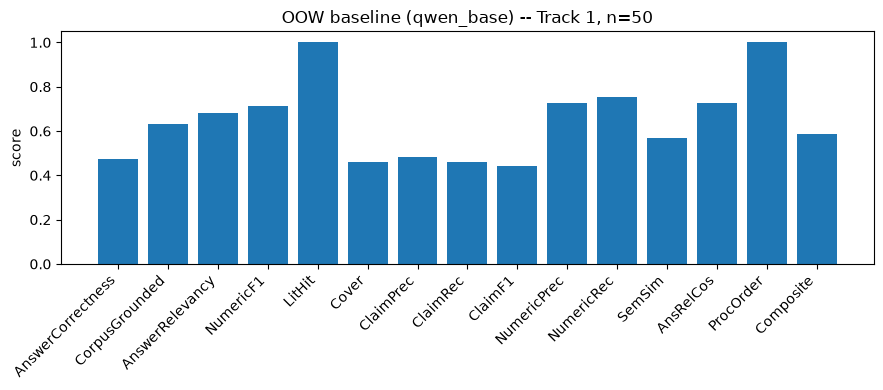

In [26]:
import matplotlib.pyplot as plt

# Reuses the summary loaded/printed by the cell above (re-run that cell first
# if you're executing this one in isolation).
means = {k: v for k, v in oow_qwen_base_summary["means"].items() if v is not None}
plt.figure(figsize=(9, 4))
plt.bar(means.keys(), means.values())
plt.title(f"OOW baseline (qwen_base) -- Track 1, n={oow_qwen_base_summary['n']}")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### § 10.1 — Baseline, Track 2 (applied helm/engine-order decisions)

Same base Qwen, now against the 300 held-out COLREG scenarios (`pipeline/eval/eval_oow_scenarios.py`,
analogous to VHF's § 10 Track 2 cell) -- rule-based ActionCorrect/DirectionCorrect/RuleCite plus the
claim-level RAGAS suite v2. Uses the `oow_colreg_scenarios_claims.json` enrichment.


In [27]:
_tag = smoke_tag("oow_qwen_base")
oow_qwen_base_colreg_summary = ensure_and_record(
    "track2", _tag,
    CACHE / f"eval_{_tag}_colreg_summary.json",
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_oow_scenarios",
     "--model", "Qwen/Qwen3-8B", "--tag", _tag, "--force-4bit"] + n_arg(300),
    baseline=_tag,
)


[skip] valid suite-v2 summary already on disk (eval_oow_qwen_base_smoke_colreg_summary.json) -- not recomputing.

=== scoreboard: track2 ===
label                 ActionCorrect DirectionCorrect RuleCite AnswerCorrectness ClaimPrec ClaimRec  ClaimF1 CorpusGrounded AnswerRelevancy NumericF1 NumericPrec NumericRec   LitHit    Cover   SemSim AnsRelCos Composite     Δbase
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
oow_qwen_base_smoke           0.760            0.000    0.760             0.345     0.188    0.420    0.255          0.259           0.143     0.226       0.156      0.521    1.000    0.667    0.616     0.201     0.367    +0.000


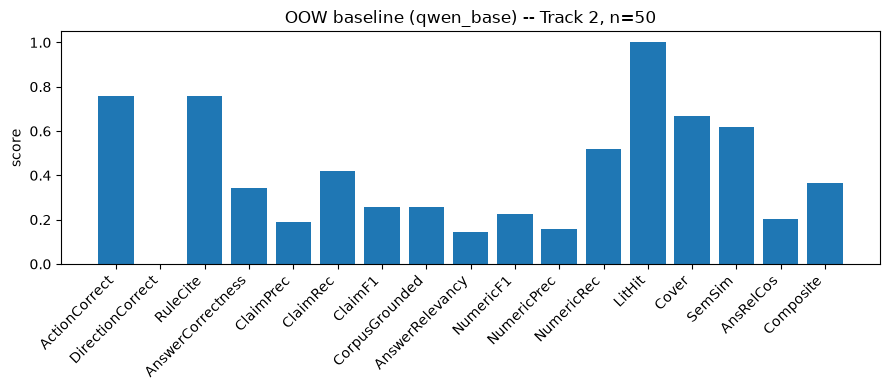

In [28]:
import matplotlib.pyplot as plt

# Reuses the summary loaded/printed by the cell above (re-run that cell first
# if you're executing this one in isolation).
means = {k: v for k, v in oow_qwen_base_colreg_summary["means"].items() if v is not None}
plt.figure(figsize=(9, 4))
plt.bar(means.keys(), means.values())
plt.title(f"OOW baseline (qwen_base) -- Track 2, n={oow_qwen_base_colreg_summary['n']}")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## § 11 — Prompt ablation: RAG/CoT-in-the-prompt vs. plain base (before any fine-tuning)

Before spending GPU time on fine-tuning, check how much of the available Track 1 knowledge can be
captured just by **prompting** the base model with retrieved context and/or a chain-of-thought
instruction -- no weights touched. Same V0-V6 design as VHF's own § 11 ablation
(`pipeline/eval/prep_ablation.py` / `run_ablation.py` / `score_ablation.py`, domain-parametrized
via `AgentPaths.from_env()` exactly like the rest of the pipeline):

- **v0_base** — plain question, no context, no reasoning instruction (same as the § 10 baseline).
- **v1_rag** — the top-k retrieved RAG chunks (built in § 3) injected as context.
- **v2_cot** — a chain-of-thought instruction, no retrieved context.
- **v3_rag_cot** — both together.
- **v4_pg** — a "Procedure guidance" block rendered from the merged Procedural Graph (§ 8, all
  traces) in the prompt; questions without a renderable path fall back to the v0 prompt at run time.
- **v5_pg_incident** — same, but guidance is rendered from `oow_pg_incident.json` alone (real-incident
  "what went wrong" steps only) -- measures whether incident-derived procedure knowledge alone helps.
- **v6_pg_scenario** — same, from `oow_pg_scenario.json` alone (Track 2's near-trivial
  assess→role→execute backbone) -- measures whether the deterministic decision structure alone helps.

v5/v6 only appear once their PG file has been built (§ 8); each is scored and compared exactly like
v4_pg, so each source's individual contribution to prompt-time guidance is separately measurable.

**Scoring uses the claim-level RAGAS suite v2** (see VHF notebook § 9 for the full metric table):
the RAG configs get real RAGAS Faithfulness + ContextPrecision/ContextRecall (contexts recovered from
`ablation_prompts.json`), the closed-book configs get CorpusGrounded; AnswerCorrectness (claim F1 vs
§ 7's `gold_claims`), AnswerRelevancy, role-aware NumericF1, LitHit, Cover and ProcOrder (reported,
not in the composite) apply everywhere. Composite weights are fixed per config kind and the summary
includes paired-bootstrap 95% CIs of each config vs v0_base. Requires § 7's
`colreg_qa_500_normalised_claims.json` — pass it via `--gold-file`; `--legacy` reproduces the old v1
metrics for comparison with historical numbers.

For VHF, this ordering turned out to matter a lot: v3_rag_cot (0.511) beat both the plain base (0.476)
**and** every fine-tuned checkpoint tried so far (0.24-0.31, before the `assistant_only_loss` fix) --
strong evidence that the underlying knowledge is genuinely useful, and that problems seen after
fine-tuning are about *how* that knowledge gets baked into weights, not whether the knowledge itself
is any good. Running this for OOW before committing to § 13 gives the same sanity check here.
(Historical note: the n=40 COLREG-only ablation preserved in `ablation_*_colreg_only_n40.*` was scored
with the old `legacy_v1` suite — don't compare those numbers against `ragas_v2.0` summaries.)

In [29]:
# SMOKE_TEST -> SMOKE_N questions x 4-5 configs, written to *_smoke files; full run -> all 500
# in the regular ablation_* files. ablation_tag_args() keeps the two from ever mixing.
run_streamed([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.prep_ablation",
    "--gold-file", str(NORM_FILE),
] + n_arg(500) + ablation_tag_args(), W)


Total gold: 500
Stratified sample: n=2
Sections covered: 2
Loading embedder (CPU-friendly for retrieval)...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 912.01it/s]
C:\Users\jcsch\Documents\Python\Auto Pilot\pipeline\ingest\pg_guidance.py:59: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  expected_dim = embedder.get_sentence_embedding_dimension()
  prepped 1/2
  prepped 2/2
  v4_pg guidance rendered for 2/2 questions (others fall back to the v0 prompt at run time)
  v5_pg_incident guidance rendered for 0/2 questions (others fall back to the v0 prompt at run time)
  v6_pg_scenario guidance rendered for 0/2 questions (others fall back to the v0 prompt at run time)

Saved: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\ablation_prompts_smoke.json  (52.9 KB)


In [30]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.run_ablation"]
             + ablation_tag_args(), W)


Prompts loaded: 2 Q's x 7 configs = 14 generations
Already done: 260
Loading Qwen/Qwen3-8B in 4-bit NF4...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!

Loading weights: 100%|██████████| 399/399 [00:14<00:00, 27.04it/s]
  VRAM allocated: 5.67 GB

Done in 0.0 min
Output: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\ablation_answers_smoke.jsonl  (426.1 KB)


In [36]:
# New-suite scoring needs the gold_claims sibling of the OOW gold file (§12.9).
_ablation_args = ablation_tag_args()
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.score_ablation",
             "--gold-file", str(NORM_FILE)] + _ablation_args, W)

import json
_ablation_suffix = "_smoke" if SMOKE_TEST else ""
summary = json.loads((paths.cache_dir / f"ablation_summary{_ablation_suffix}.json").read_text())
print(f"metric_suite: {summary.get('_meta', {}).get('metric_suite', 'legacy_v1')}")
for cfg, means in summary.items():
    if cfg == "_meta":
        continue
    # Only the scalar metric means go into the scoreboard -- Composite_vs_v0_base is a
    # {delta, ci_lo, ci_hi, significant} dict (printed separately below), not a metric value.
    record("track1", cfg, {k: v for k, v in means.items() if not isinstance(v, dict)})
    ci = means.get("Composite_vs_v0_base")
    if ci and ci.get("delta") is not None:
        print(f"  {cfg:<12} Δvs_v0={ci['delta']:+.3f} [{ci['ci_lo']:+.3f},{ci['ci_hi']:+.3f}]"
              f"{' *' if ci.get('significant') else ' (noise)'}")
print_scoreboard("track1", baseline="v0_base")


Loading embedder...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1569.42it/s]
  [filter] 246 stale answers from earlier --n/seed samples excluded (not in current ablation_prompts_smoke.json)
Records to score: 14
C:\Users\jcsch\Documents\Python\Auto Pilot\pipeline\ingest\pg_guidance.py:59: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  expected_dim = embedder.get_sentence_embedding_dimension()
C:\Users\jcsch\Documents\Python\Auto Pilot\pipeline\eval\ragas_metrics.py:370: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  expected_dim = self.embedder.get_sentence_embedding_dimension()
  scored 1/14  cfg=v0_base
  scored 2/14  cfg=v0_base
  scored 3/14  cfg=v1_rag
  scored 4/14  cfg=v1_rag
  scored 5/14  cfg=v2_cot
  scored 6/14  cfg=v2_cot
  scored 7/14  cfg=v3_rag_cot
  scored 8/14  cfg=v3_rag_cot
  scored 9/14  cfg=v4_pg
  scored 10/14  cfg=v4_pg
  score

### § 11.1 — Prompt ablation, Track 2 (applied helm/engine-order decisions)

Same V0-V4 prompt configs, but against the 300 held-out COLREG scenarios instead of the gold Q&A --
does RAG/CoT/PG help the model actually DECIDE and STATE the correct action, not just recall rules?
System prompt is always the fixed Track 2 response-format contract (`SYSTEM_OOW`); only the user turn
gains a CoT instruction and/or retrieved context. Scored with the claim-level suite plus the rule-based
ActionCorrect/DirectionCorrect/RuleCite metrics from `eval_oow_scenarios.py` (no unified composite for
these three, same as at eval time -- see § 13.3). Same three scripts, `--track2` flag.


In [37]:
run_streamed([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.prep_ablation", "--track2",
] + n_arg(300) + ablation_tag_args(), W)


Total gold: 300
Stratified sample: n=2
Categories covered: 2
Loading embedder (CPU-friendly for retrieval)...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1083.18it/s]
C:\Users\jcsch\Documents\Python\Auto Pilot\pipeline\ingest\pg_guidance.py:59: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  expected_dim = embedder.get_sentence_embedding_dimension()
  prepped 1/2
  prepped 2/2
  v4_pg guidance rendered for 2/2 questions (others fall back to the v0 prompt at run time)
  v5_pg_incident guidance rendered for 2/2 questions (others fall back to the v0 prompt at run time)
  v6_pg_scenario guidance rendered for 2/2 questions (others fall back to the v0 prompt at run time)

Saved: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\ablation_prompts_track2_smoke.json  (88.3 KB)


In [38]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.run_ablation", "--track2"]
             + ablation_tag_args(), W)


Prompts loaded: 2 Q's x 7 configs = 14 generations
Already done: 39
Loading Qwen/Qwen3-8B in 4-bit NF4...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!

Loading weights: 100%|██████████| 399/399 [00:11<00:00, 34.39it/s]
  VRAM allocated: 5.67 GB

Done in 0.0 min
Output: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\ablation_answers_track2_smoke.jsonl  (154.5 KB)


In [39]:
_ablation_args_t2 = ablation_tag_args()
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.score_ablation", "--track2"]
             + _ablation_args_t2, W)

_ablation_suffix_t2 = "_smoke" if SMOKE_TEST else ""
summary_t2 = json.loads((paths.cache_dir / f"ablation_summary_track2{_ablation_suffix_t2}.json").read_text())
print(f"metric_suite: {summary_t2.get('_meta', {}).get('metric_suite', 'legacy_v1')}")
for cfg, means in summary_t2.items():
    if cfg == "_meta":
        continue
    record("track2", cfg, {k: v for k, v in means.items() if not isinstance(v, dict)})
    ci = means.get("Composite_vs_v0_base")
    if ci and ci.get("delta") is not None:
        print(f"  {cfg:<12} Δvs_v0={ci['delta']:+.3f} [{ci['ci_lo']:+.3f},{ci['ci_hi']:+.3f}]"
              f"{' *' if ci.get('significant') else ' (noise)'}")
print_scoreboard("track2", baseline="v0_base")


Loading embedder...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1230.88it/s]
  [filter] 25 stale answers from earlier --n/seed samples excluded (not in current ablation_prompts_track2_smoke.json)
Records to score: 14
C:\Users\jcsch\Documents\Python\Auto Pilot\pipeline\ingest\pg_guidance.py:59: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  expected_dim = embedder.get_sentence_embedding_dimension()
C:\Users\jcsch\Documents\Python\Auto Pilot\pipeline\eval\ragas_metrics.py:370: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  expected_dim = self.embedder.get_sentence_embedding_dimension()
  scored 1/14  cfg=v0_base
  scored 2/14  cfg=v0_base
  scored 3/14  cfg=v1_rag
  scored 4/14  cfg=v1_rag
  scored 5/14  cfg=v2_cot
  scored 6/14  cfg=v2_cot
  scored 7/14  cfg=v3_rag_cot
  scored 8/14  cfg=v3_rag_cot
  scored 9/14  cfg=v4_pg
  scored 10/14  cfg=v4_pg
 

---
## § 12 — Data-coverage gap analysis (reuse, no changes needed)

`pipeline/eval/analyze_gaps.py` is domain-agnostic by design (no VHF/COLREG field names hardcoded) --
point it at the baseline eval file from § 10, grouped by `section_id` (here, COLREG rule reference).


In [40]:
result = subprocess.run(
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.analyze_gaps",
     "--eval-file", str(CACHE / f"eval_{smoke_tag('oow_qwen_base')}.jsonl"),
     "--group-by", "section_id"],
    cwd=W, capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Loaded 50 rows from C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\eval_oow_qwen_base_smoke.jsonl
DATA-COVERAGE GAP ANALYSIS  â€”  grouped by 'section_id'  (50 rows across 10 groups)

Group                                            n  MeanComposite
Rule 4                                           1          0.457
Rule 1                                           3          0.510
Rule 6                                           4          0.549
Rule 9                                           7          0.557
Rule 3                                          10          0.567
Rule 10                                          8          0.572
Rule 2                                           2          0.575
Rule 7                                           6          0.623
Rule 8                                           7          0.654
Rule 5                                           2          0.770

WORST 8 GROUPS â€” likely data-coverage gaps, worst first

--- R

---
## § 12.1 — Cross-source consistency check (framework reuse; fact-list is a TODO)

`pipeline/eval/check_consistency.py`'s *mechanism* (quote-scoped regex checks over every parsed JSON
section) is reusable, but its actual fact lists (`PHONETIC_ALPHABET`, `REPEAT_PROWORDS`,
`NUMBER_WORDS`) are VHF-specific and don't apply to COLREG text -- so this will currently report **zero
findings** for OOW, which is expected, not a sign everything is consistent. A COLREG-appropriate
Level-1 fact list (e.g. rule-number ↔ rule-title cross-references, light/shape/sound-signal
specifications that have exactly one correct answer) is a follow-up, not required before § 13.


In [41]:
result = subprocess.run(
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.check_consistency"],
    cwd=W, capture_output=True, text=True,
)
print(result.stdout[-3000:])
if result.returncode != 0:
    print(result.stderr)

CROSS-SOURCE CONSISTENCY CHECK (Level 1)  â€”  0 finding(s)
No known-standard violations found. (This only checks the fixed list of facts
in PHONETIC_ALPHABET / REPEAT_PROWORDS above â€” it is not a general contradiction
detector; see the module docstring for why.)

Saved: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\consistency_findings.json



---
## § 13 · Fine-tuning OOW-QWEN (3 stages)

Identical stages/hyperparameters to VHF -- `train_sft.py` → `train_dpo.py` → `train_reflection.py`,
each domain-aware via `AgentPaths.from_env()` and saving to
`_models/OOW/oow_qwen_{sft,dpo,reflect}_lora/`. `SFT_DATASETS`/`DPO_FILES`/`REFL_FILES` in those three
scripts are keyed by `paths.domain`, so OOW's file lists (rule-text Track 1 from § 6 + real-incident
excerpts from § 6.1 + PG step-order data from § 8) are picked up automatically -- no CLI flags needed.
DPO pairs now include the 6th perturbation axis `swap_step_order` (§ 8). Cross-track multi-hop
(rule text <-> incident) is already folded into `oow_multihop.jsonl` from § 6. Track 2
(applied helm/engine-order decisions, § 6.5) is still not built, so this trains COLREG
rules/knowledge + real-incident reasoning only, until Track 2 data exists and is added to each
script's file list.

Stage 1 — SFT. Adapter ~50 MB.


In [ ]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.train_sft"]
             + smoke_train_args() + dry_run_args()
             + (["--out-dir", str(smoke_dir("oow_qwen_sft_lora")), "--force"] if SMOKE_TEST else []), W)

VHF-QWEN — Stage 1 SFT (Supervised Fine-Tuning with QLoRA)

Loading SFT datasets...
  oow_sft_direct.jsonl            1253 rows
  oow_sft_cot.jsonl               1253 rows
  oow_sft_rag.jsonl               1253 rows
  oow_multihop.jsonl              1541 rows
  oow_incident_sft_direct.jsonl    214 rows
  oow_incident_sft_cot.jsonl       214 rows
  oow_incident_sft_rag.jsonl       214 rows
  oow_scenario_sft_direct.jsonl    360 rows
  oow_scenario_sft_cot.jsonl       360 rows
  oow_pg_sft.jsonl                 624 rows
  oow_pg_incident_sft.jsonl         12 rows
  TOTAL SFT (shuffled)            7298 rows
Loading Qwen/Qwen3-8B in 4-bit NF4...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!

Loading weights: 100%|██████████| 399/399 [00:11<00:00, 34.84it/s]

Tokenizing train dataset: 100%|██████████| 7298/7298 [00:07<00:00, 1009.12 examples/s]

Building labels for train dataset: 100%|██████████| 7298/7298 [00:01<00:00, 6218.81 examples/s]

Truncating train dataset: 100%|

Stage 2 — DPO. Adapter ~25 MB.

In [ ]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.train_dpo"]
             + smoke_train_args() + dry_run_args()
             + (["--out-dir", str(smoke_dir("oow_qwen_dpo_lora")),
                 "--sft-dir", str(smoke_dir("oow_qwen_sft_lora")), "--force"] if SMOKE_TEST else []), W)

Stage 3 — Reflection. Adapter ~25 MB.

In [ ]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.train_reflection"]
             + smoke_train_args() + dry_run_args()
             + (["--out-dir", str(smoke_dir("oow_qwen_reflect_lora")),
                 "--sft-dir", str(smoke_dir("oow_qwen_sft_lora")),
                 "--dpo-dir", str(smoke_dir("oow_qwen_dpo_lora")), "--force"] if SMOKE_TEST else []), W)

---
## § 13.1 · Merge → OOW-QWEN (single deployable model)


In [ ]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.merge_adapter"]
             + dry_run_args()
             + (["--output", str(smoke_dir("OOW-QWEN")),
                 "--sft-dir", str(smoke_dir("oow_qwen_sft_lora")),
                 "--dpo-dir", str(smoke_dir("oow_qwen_dpo_lora")),
                 "--reflect-dir", str(smoke_dir("oow_qwen_reflect_lora")), "--force"] if SMOKE_TEST else []), W)

---
## § 13.2 · Evaluate OOW-QWEN on the 500 held-out COLREG Q&A (Track 1)

Closed-book (no prompt tricks) — measures what the fine-tune internalized. Scored with the claim-level
RAGAS suite v2 (AnswerCorrectness, CorpusGrounded, AnswerRelevancy, NumericF1, LitHit, Cover, fixed-weight
Composite — see VHF notebook § 9 for definitions and why the old suite was replaced). Requires § 7's
`colreg_qa_500_normalised_claims.json`; `--legacy` reproduces the old metrics. Summaries are stamped with
`metric_suite` — never compare `ragas_v2.0` numbers against `legacy_v1` numbers.


In [ ]:
_tag = smoke_tag("oow_qwen")
oow_qwen_summary = ensure_and_record(
    "track1", _tag,
    CACHE / f"eval_{_tag}_summary.json",
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_finetuned",
     "--model", str(smoke_dir("OOW-QWEN")), "--tag", _tag,
     "--gold-file", str(NORM_FILE), "--force-4bit"] + n_arg(500),
    baseline=smoke_tag("oow_qwen_base"),
)


In [ ]:
import matplotlib.pyplot as plt

# Reuses the summary loaded/printed by the cell above (re-run that cell first
# if you're executing this one in isolation).
means = {k: v for k, v in oow_qwen_summary["means"].items() if v is not None}
plt.figure(figsize=(9, 4))
plt.bar(means.keys(), means.values())
plt.title(f"OOW-QWEN -- Track 1, n={oow_qwen_summary['n']}")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### § 13.3 — Track 2: Evaluate OOW-QWEN on the 300 held-out COLREG scenarios (applied helm/engine-order decisions)

Where § 13.2 asks whether the model knows the rule, this asks whether the model can actually DECIDE
and STATE the correct action. Code: `eval_oow_scenarios.py` (requires `oow_colreg_scenarios_claims.json`,
produced in this session). Note: base Qwen's Track 2 number was already computed in § 10.1; this
section starts from the fine-tuned `oow_qwen` tag for direct comparison.


In [ ]:
_tag = smoke_tag("oow_qwen")
oow_qwen_colreg_summary = ensure_and_record(
    "track2", _tag,
    CACHE / f"eval_{_tag}_colreg_summary.json",
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_oow_scenarios",
     "--model", str(smoke_dir("OOW-QWEN")), "--tag", _tag, "--force-4bit"] + n_arg(300),
    baseline=smoke_tag("oow_qwen_base"),
)



In [ ]:
import matplotlib.pyplot as plt

# Reuses the summary loaded/printed by the cell above (re-run that cell first
# if you're executing this one in isolation).
means = {k: v for k, v in oow_qwen_colreg_summary["means"].items() if v is not None}
plt.figure(figsize=(9, 4))
plt.bar(means.keys(), means.values())
plt.title(f"OOW-QWEN -- Track 2, n={oow_qwen_colreg_summary['n']}")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## § 13.4 · Stage-attribution probes — did DPO and Reflection actually do their jobs?

Aggregate eval deltas can't say WHICH training stage helped. [probe_dpo.py](pipeline/eval/probe_dpo.py)
measures each stage's job directly, on a deterministic **held-out** probe set built from the gold file
(cached in `probe_set.json`). See VHF notebook § 13.4 for the full explanation of the DPO probe
(per-axis log-likelihood win-rate, including `swap_step_order`) and the reflection probe (Δ
AnswerCorrectness, revision − draft). Run once per checkpoint — GPU-bound, cloud pod or `--force-4bit`
locally.


In [ ]:
for model_path, raw_tag in [
    ("Qwen/Qwen3-8B", "oow_qwen_base"),
    (str(smoke_dir("OOW-QWEN")), "oow_qwen"),
]:
    tag = smoke_tag(raw_tag)
    out = CACHE / f"probe_{tag}.json"
    if out.exists():
        print(f"[skip] {out.name} already exists -- not recomputing.")
    else:
        run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.probe_dpo",
                     "--model", model_path, "--tag", tag,
                     "--gold-file", str(NORM_FILE), "--force-4bit"]
                    + probe_smoke_args(), W)
    record_probe(tag, out)


---
## § 14 · Compression 1 — AWQ int4 quantization


In [ ]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.compress.compress_quantize_awq"]
             + dry_run_args()
             + (["--input", str(smoke_dir("OOW-QWEN")), "--output", str(smoke_dir("OOW-QWEN-awq-int4")),
                 "--n-calibration", "4"] if SMOKE_TEST else []), W)

---
## § 14.1 · Compression 2 — Layer pruning (ShortGPT-style)


In [ ]:
run_streamed([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.compress.compress_prune", "--n-prune", "4",
] + dry_run_args() + (["--input", str(smoke_dir("OOW-QWEN")), "--output", str(smoke_dir("OOW-QWEN-pruned")),
      "--n-calib", "4"] if SMOKE_TEST else []), W)

---
## § 14.2 · Compression 3 — Knowledge Distillation → DistillOOW-QWEN


In [ ]:
run_streamed([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.compress.compress_distill"]
             + smoke_distill_args() + dry_run_args()
             + (["--teacher-dir", str(smoke_dir("OOW-QWEN")),
                 "--output", str(smoke_dir("DistillOOW-QWEN"))] if SMOKE_TEST else []), W)

---
## § 15 · Final comparison — all model tags, both tracks

Backfill eval for the AWQ/pruned/distilled tags (both tracks), then compare everything side by side
(same shape as VHF's § 15 comparison table + plots).


In [ ]:
tags_and_models = [
    ("oow_qwen_awq",      smoke_dir("OOW-QWEN-awq-int4")),
    ("oow_qwen_pruned",   smoke_dir("OOW-QWEN-pruned")),
    ("distill_oow_qwen",  smoke_dir("DistillOOW-QWEN")),
]
for raw_tag, model_dir in tags_and_models:
    if not model_dir.exists():
        print(f"  (skipping {raw_tag} -- {model_dir} not found)")
        continue
    tag = smoke_tag(raw_tag)
    ensure_and_record(
        "track1", tag,
        CACHE / f"eval_{tag}_summary.json",
        [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_finetuned",
         "--model", str(model_dir), "--tag", tag, "--gold-file", str(NORM_FILE), "--force-4bit"] + n_arg(500),
        baseline=smoke_tag("oow_qwen_base"),
    )


In [ ]:
# Track 2 backfill for the same AWQ/pruned/distilled tags -- oow_qwen_base and oow_qwen were
# already computed in § 10.1 and § 13.3, so this loop starts straight from oow_qwen_awq.
for raw_tag, model_dir in tags_and_models:
    if not model_dir.exists():
        continue
    tag = smoke_tag(raw_tag)
    ensure_and_record(
        "track2", tag,
        CACHE / f"eval_{tag}_colreg_summary.json",
        [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_oow_scenarios",
         "--model", str(model_dir), "--tag", tag, "--force-4bit"] + n_arg(300),
        baseline=smoke_tag("oow_qwen_base"),
    )



In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for raw_tag in ["oow_qwen_base", "oow_qwen", "oow_qwen_awq", "oow_qwen_pruned", "distill_oow_qwen"]:
    tag = smoke_tag(raw_tag)
    p1 = paths.cache_dir / f"eval_{tag}_summary.json"
    p2 = paths.cache_dir / f"eval_{tag}_colreg_summary.json"
    if not p1.exists() and not p2.exists():
        continue
    row = {"tag": tag, "Track1_RulesKnowledge": None, "Track2_HelmEngineDecisions": None,
           "latency_mean_s": None}
    if p1.exists():
        s1 = json.loads(p1.read_text())
        row["n_track1"] = s1["n"]
        row["Track1_RulesKnowledge"] = s1["means"].get("Composite")
        row["latency_mean_s"] = s1.get("latency", {}).get("mean_s")
    if p2.exists():
        s2 = json.loads(p2.read_text())
        row["n_track2"] = s2["n"]
        row["Track2_HelmEngineDecisions"] = s2["means"].get("Composite")
        row["Track2_ActionCorrect"] = s2["means"].get("ActionCorrect")
        if row["latency_mean_s"] is None:
            row["latency_mean_s"] = s2.get("latency", {}).get("mean_s")
    rows.append(row)

pd.set_option("display.width", 140)
df = pd.DataFrame(rows).set_index("tag")
print(df.to_string())

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(19, 4))
    df["Track1_RulesKnowledge"].dropna().plot(kind="barh", ax=axes[0], color="#4e9af1",
                                              title="Track 1 -- Rules knowledge\n(higher = better)")
    axes[0].set_xlim(0, 1)
    axes[0].grid(True, axis="x", alpha=0.3)
    df["Track2_HelmEngineDecisions"].dropna().plot(kind="barh", ax=axes[1], color="#8e44ad",
                                                    title="Track 2 -- Helm/engine decisions\n(higher = better)")
    axes[1].set_xlim(0, 1)
    axes[1].grid(True, axis="x", alpha=0.3)
    df["latency_mean_s"].dropna().plot(kind="barh", ax=axes[2], color="#f1914e",
                                       title="Mean latency per answer\n(lower = better)")
    axes[2].set_xlabel("seconds")
    axes[2].grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    plt.savefig(paths.cache_dir / "oow_final_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {paths.cache_dir / 'oow_final_comparison.png'}")
